# Лаба 1, Задание 1 📝

### 1. Синтетический тест: Концентрация меры на сфере $\mathbb{S}^{d-1}$

In [2]:
import numpy
import pandas
import seaborn
import matplotlib.pyplot
import scipy

In [3]:
# Количество векторов.
M = 20000

# Размерности пространств.
D = [16, 64, 256, 512, 4096]
S = [0] * len(D)

In [4]:
for iteration, d in enumerate(D):
    X = numpy.array([
        numpy.random.normal(0.0, 1.0, (d)) for _ in range(M)
    ])
    
    Y = numpy.array([
        numpy.random.normal(0.0, 1.0, (d)) for _ in range(M)
    ])
    
    for i in range(M):
        X[i] /= numpy.linalg.norm(X[i])
        Y[i] /= numpy.linalg.norm(Y[i])

    s = numpy.zeros(M)

    for i in range(M):
        s[i] = numpy.dot(X[i], Y[i])

    S[iteration] = s

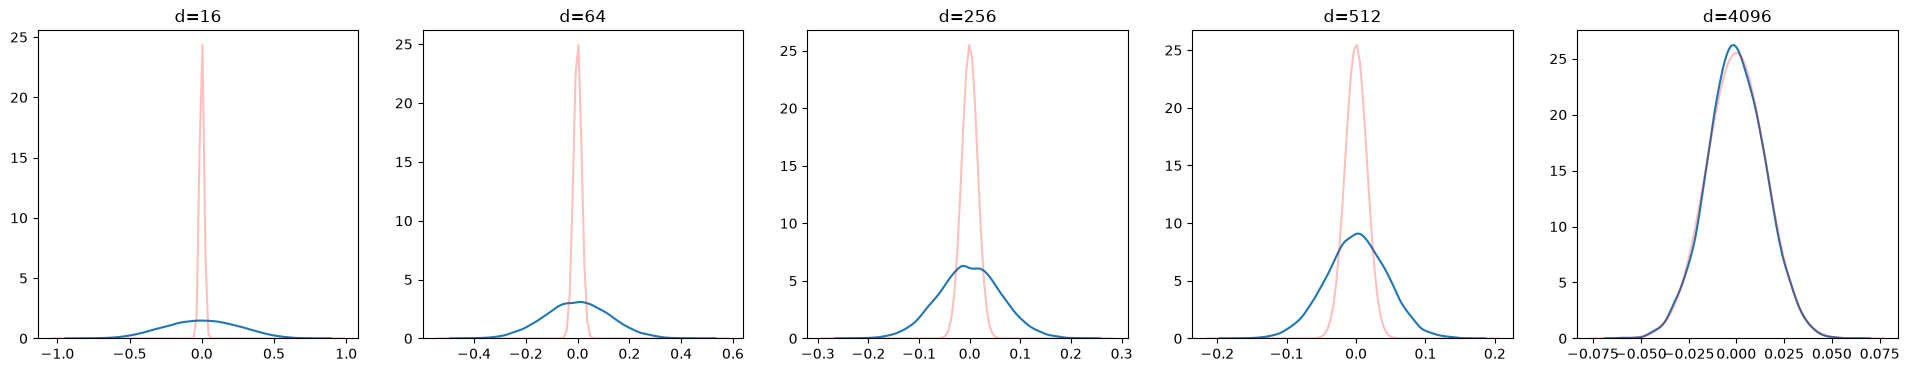

In [5]:
fig, axs = matplotlib.pyplot.subplots(ncols=len(D), figsize=(24, 4))

for iteration, s in enumerate(S):
    ax = seaborn.kdeplot(s, ax=axs[iteration])

    x0, x1 = ax.get_xlim()
    x_pdf = numpy.linspace(x0, x1, 100)
    y_pdf = scipy.stats.norm.pdf(x_pdf, 0.0, numpy.sqrt(1.0/d))
    
    ax.plot(x_pdf, y_pdf, 'red', alpha=0.25)
    ax.set_ylabel("")
    ax.set_title(f"d={D[iteration]}")

In [6]:
theoretical_variance = []
practical_mean = []
practical_variance = []

for iteration, d in enumerate(D):
    s = S[iteration]
    tv = 1.0/d
    pm = s.sum() / M
    pv = ((s - pm)**2).sum() / M

    theoretical_variance.append(tv)
    practical_mean.append(pm)
    practical_variance.append(pv)

In [7]:
pandas.DataFrame({
    "d": D,
    "theoretical_variance": theoretical_variance,
    "practical_mean": practical_mean,
    "practical_variance": practical_variance,
})

,d,theoretical_variance,practical_mean,practical_variance
0,16,0.062500,0.002449,0.062844
1,64,0.015625,-0.001325,0.015654
2,256,0.003906,0.000126,0.003910
3,512,0.001953,0.000765,0.001967
4,4096,0.000244,-0.000101,0.000236


### 2. Transformers

In [9]:
import transformers

[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
